# Dark Photon FIRAS Constraints

Generates `dp_firas_pde_constraints.pdf` (Figure 8 in paper).

FIRAS 95% CL upper limits on dark photon kinetic mixing epsilon as a function of mass, via PDE spectral fit with floating-T profile likelihood.

In [ ]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from spectroxide import (
    greens_function, run_sweep, solve,
    mu_shape, y_shape, g_bb, planck,
    j_mu, j_y, j_bb, j_bb_star,
    KAPPA_C, G3_PLANCK, G2_PLANCK,
    DEFAULT_COSMO, PLANCK2015_COSMO, PLANCK2018_COSMO,
    delta_n_to_delta_I, decompose_distortion,
    ionization_fraction,
    apply_style,
    load_or_build_greens_table, GreensTable,
)
from spectroxide.firas import FIRASData
from spectroxide.greens import (
    _cosmo_hubble, _cosmo_n_e, _cosmo_omega_gamma,
    _C_LIGHT, _K_BOLTZMANN, _HBAR,
)
from spectroxide.plot_params import (
    C, DOUBLE_COL, SINGLE_COL, LW, LW_THICK, LW_THIN,
    LABEL_SIZE, LEGEND_SIZE, ANNOT_SIZE,
)

# Constants
ALPHA_FS = 7.297_352_5693e-3
M_ELECTRON = 9.109_383_7015e-31  # kg
EV_IN_JOULES = 1.602_176_634e-19
HBAR_EV_S = _HBAR / EV_IN_JOULES
G1_PLANCK = np.pi**2 / 6.0

apply_style()

cosmo = DEFAULT_COSMO
results = []


## Physics: plasma frequency, resonance redshift

In [2]:
def plasma_frequency_ev(z, cosmo=DEFAULT_COSMO):
    """Photon plasma frequency [eV] at redshift z."""
    n_e = _cosmo_n_e(z, cosmo)
    omega_pl_sq = 4 * np.pi * ALPHA_FS * _HBAR * _C_LIGHT * n_e / M_ELECTRON
    return HBAR_EV_S * np.sqrt(omega_pl_sq)

def resonance_redshift(m_dp_ev, cosmo=DEFAULT_COSMO, z_min=10, z_max=3e7):
    """Find z_res where omega_pl(z_res) = m_dp using bisection."""
    def f(z):
        return plasma_frequency_ev(z, cosmo) - m_dp_ev
    if f(z_min) * f(z_max) > 0:
        return None
    return brentq(f, z_min, z_max)

# Map mass range to resonance redshifts


## Spectral integrals

In [3]:
# Spectral integrals
g1 = G1_PLANCK  # pi^2/6
g2 = G2_PLANCK  # 2*zeta(3)
g3 = G3_PLANCK  # pi^4/15
kappa_c = KAPPA_C

ratio_g2_g3 = g2 / g3
ratio_g1_g2 = g1 / g2
three_over_kappa = 3.0 / kappa_c

# Entropy-corrected mu coefficient (Chluba & Cyr Eq. 9)
entropy_factor = -ratio_g2_g3 + (4.0/3.0) * ratio_g1_g2
mu_coeff_corrected = three_over_kappa * entropy_factor
mu_coeff_energy_only = three_over_kappa * ratio_g2_g3

print(f"G_2/G_3 = {ratio_g2_g3:.4f}  (target: 0.3702)")
print(f"G_1/G_2 = {ratio_g1_g2:.4f}  (target: 0.6842)")
print(f"3/kappa = {three_over_kappa:.4f}  (target: 1.4007)")
print(f"mu coeff (entropy-corrected): {mu_coeff_corrected:.4f}  (target: +0.7593)")
print(f"mu coeff (energy-only):       {mu_coeff_energy_only:.4f}  (target: 0.5185)")
print(f"Sign reversal: corrected is POSITIVE, energy-only would give NEGATIVE mu")


G_2/G_3 = 0.3702  (target: 0.3702)
G_1/G_2 = 0.6842  (target: 0.6842)
3/kappa = 1.4007  (target: 1.4007)
mu coeff (entropy-corrected): 0.7593  (target: +0.7593)
mu coeff (energy-only):       0.5185  (target: 0.5185)
Sign reversal: corrected is POSITIVE, energy-only would give NEGATIVE mu


## Conversion parameter gamma_con

In [4]:
def dln_omega_pl2_dlna(z, cosmo=DEFAULT_COSMO):
    """Numerical |d ln omega_pl^2 / d ln(1+z)| at redshift z.
    
    omega_pl^2 propto X_e(z) * (1+z)^3, so
    d ln omega_pl^2 / d ln(1+z) = (1+z) * d ln X_e/dz + 3.
    """
    dz = max(0.1, z * 1e-4)
    xe_p = ionization_fraction(z + dz, cosmo)
    xe_m = ionization_fraction(z - dz, cosmo)
    xe = ionization_fraction(z, cosmo)
    dlnxe_dz = (xe_p - xe_m) / (2 * dz * xe) if xe > 1e-30 else 0.0
    return abs((1.0 + z) * dlnxe_dz + 3.0)


def gamma_con(epsilon, m_ev, cosmo=DEFAULT_COSMO):
    """Compute gamma_con from Chluba & Cyr (2024) Eq. 6."""
    z_res = resonance_redshift(m_ev, cosmo)
    if z_res is None:
        return None, None
    T_cmb_ev = _K_BOLTZMANN * cosmo["t_cmb"] * (1 + z_res) / EV_IN_JOULES
    H_ev = HBAR_EV_S * _cosmo_hubble(z_res, cosmo)
    dlna = dln_omega_pl2_dlna(z_res, cosmo)
    gc = np.pi * epsilon**2 * m_ev**2 / (dlna * T_cmb_ev * H_ev)
    return gc, z_res


def gc_per_eps2(m_ev, z_res, cosmo=DEFAULT_COSMO):
    """gamma_con / epsilon^2 at resonance redshift."""
    T_cmb_ev = _K_BOLTZMANN * cosmo["t_cmb"] * (1 + z_res) / EV_IN_JOULES
    H_ev = HBAR_EV_S * _cosmo_hubble(z_res, cosmo)
    dlna = dln_omega_pl2_dlna(z_res, cosmo)
    return np.pi * m_ev**2 / (dlna * T_cmb_ev * H_ev)


# Verify epsilon^2 scaling
gc1, _ = gamma_con(1e-6, 1e-5)
gc2, _ = gamma_con(2e-6, 1e-5)
ratio = gc2 / gc1
print(f"gamma_con scaling with epsilon^2: ratio = {ratio:.4f} (expected 4.0)")
results.append(("gamma_con ~ eps^2", abs(ratio - 4.0) < 0.01, f"ratio={ratio:.4f}"))


gamma_con scaling with epsilon^2: ratio = 4.0000 (expected 4.0)


## FIRAS data and profile likelihood

In [ ]:
# Load FIRAS data with full covariance matrix
firas = FIRASData()
print(firas)

# Convenience aliases matching the rest of the notebook
x_firas = firas.x
nu_GHz_firas = firas.freq_ghz
residual_kJy = firas.residual_kJy
sigma_kJy = firas.sigma_kJy

# Convert residuals and sigma to Delta_n units for legacy compatibility
h_planck = 6.62607015e-34
k_B = 1.380649e-23
c_light = 2.99792458e8
T_CMB = 2.726

nu_Hz = firas.freq_cm * 100 * c_light
conversion = 2 * h_planck * nu_Hz**3 / c_light**2  # W/m^2/Hz/sr per unit Delta_n
sigma_dn = (sigma_kJy * 1e-23) / conversion
residual_dn = (residual_kJy * 1e-23) / conversion

# Precompute FIRAS-sampled basis functions
gbb_firas = g_bb(x_firas)
npl_firas = planck(x_firas)

# Build inverse covariance in Delta_n units: C_dn = C_kJy / (conv * conv)
# where conv_i converts Delta_n_i to kJy/sr at channel i
conv_vec = conversion * 1e23  # Delta_n -> kJy/sr
cov_dn = firas.cov / np.outer(conv_vec, conv_vec)  # (kJy/sr)^2 / (kJy/sr per dn)^2 = dn^2
cov_inv_dn = np.linalg.inv(cov_dn)

print(f'FIRAS: {len(x_firas)} channels, nu = {nu_GHz_firas[0]:.0f}--{nu_GHz_firas[-1]:.0f} GHz')
print(f'x_firas = {x_firas[0]:.2f}--{x_firas[-1]:.2f}')
print(f'Covariance matrix condition number: {np.linalg.cond(cov_dn):.1e}')


def firas_profile_limit_floating_T(template_dn_func):
    """Profile likelihood 95% CL upper limit on amplitude, floating T.

    Uses FIRASData.profile_limit_floating_T: for each trial T, recomputes
    residuals as I_obs - B(nu, T) and evaluates the template at x(T) = hnu/(kT).
    The amplitude is analytically profiled; T is numerically optimised.
    """
    result = firas.profile_limit_floating_T(template_dn_func, cl=0.95)
    return result['upper_limit'], result['amplitude'], result['sigma'], result['t_best']


def firas_profile_limit_gbb(template_per_gc):
    """Profile likelihood 95% CL upper limit on gamma_con (G_bb nuisance, fixed T).

    Legacy method: fits FIRAS residuals d = gc * template + alpha * G_bb.
    Profiles over alpha (T shift nuisance), one-sided.
    Uses full covariance matrix.
    """
    A = np.column_stack([template_per_gc, gbb_firas])
    F = A.T @ cov_inv_dn @ A
    F_inv = np.linalg.inv(F)
    theta_hat = F_inv @ (A.T @ cov_inv_dn @ residual_dn)
    gc_hat = theta_hat[0]
    sigma_gc = np.sqrt(F_inv[0, 0])
    gc_95 = max(gc_hat + 1.645 * sigma_gc, 0.0)
    return gc_95, gc_hat, sigma_gc


# Verify: floating-T on pure mu template should match standard limit
mu_limit_gbb = firas.upper_limit_mu(cl=0.95, marginalise_y=False)
mu_result_T = firas.profile_limit_floating_T(mu_shape, cl=0.95)
print(f'\nmu limit (G_bb nuisance, fixed T):  |mu| < {mu_limit_gbb:.2e}')
print(f'mu limit (floating T):               |mu| < {mu_result_T["upper_limit"]:.2e}')
print(f'  T_best = {mu_result_T["t_best"]:.6f} K')
diff_pct = abs(mu_limit_gbb - mu_result_T['upper_limit']) / mu_limit_gbb * 100
print(f'  Difference: {diff_pct:.2f}%')


## PDE templates and FIRAS fitting


In [6]:
# GF limits skipped — not needed for paper figure.
# See notebooks/physics/dark_photon_validation.ipynb for GF comparison.


## PDE worker and parallel execution

In [ ]:
# === Case 2: PDE spectral fit (floating-T profile likelihood, parallelized) ===
from concurrent.futures import ThreadPoolExecutor, as_completed


def strip_gbb_nc(x, delta_n):
    """Number-conserving G_bb subtraction: int x^2 Dn_stripped dx = 0."""
    gbb = g_bb(x)
    alpha = np.trapz(x**2 * delta_n, x) / np.trapz(x**2 * gbb, x)
    return delta_n - alpha * gbb, alpha


def run_dp_pde(epsilon, m_ev, npts):
    """Run PDE with dark photon resonance injection (modern API).
    Returns raw (un-stripped) x, delta_n.
    Solver auto-sets z_start=z_res and auto-enables NC for depletion.
    """
    result = solve(
        injection={'type': 'dark_photon_resonance',
                   'epsilon': epsilon, 'm_ev': m_ev},
        z_end=100,
        n_points=npts,
        timeout=1200,
    )
    return result.x, result.delta_n


def _pde_single_pass(m_dp, eps_ref, firas_obj, npts):
    """Single PDE run + FIRAS limit at one eps_ref.

    Returns (eps_lim, x, dn_per_gc, zr).
    """
    zr = resonance_redshift(m_dp)
    if zr is None:
        return None, None, None, None
    gpe2 = gc_per_eps2(m_dp, zr)
    gc_ref = gpe2 * eps_ref**2
    x_pde, dn_pde = run_dp_pde(eps_ref, m_dp, npts)
    dn_nc, _ = strip_gbb_nc(x_pde, dn_pde)
    dn_per_gc = dn_nc / gc_ref
    def template(x, _x=x_pde, _dn=dn_per_gc):
        return np.interp(x, _x, _dn)
    result = firas_obj.profile_limit_floating_T(template, cl=0.95)
    gc_95 = result['upper_limit']
    eps_lim = np.sqrt(gc_95 / gpe2) if gc_95 > 0 and gpe2 > 0 else np.inf
    return eps_lim, x_pde, dn_per_gc, zr


def _pde_worker(m_dp, eps_ref_init, firas_obj,
                extrap_trigger=3.0, rtol=0.05, max_iter=10):
    """Self-consistent eps_ref iteration for a single mass.

    Iteration behaviour:
      - If the first pass is within ``extrap_trigger`` of eps_ref (mildly
        linear extrapolation), accept that single pass.
      - Otherwise update eps_ref ← eps_lim and repeat.
      - The update can land on a 2-cycle (low-eps linear branch vs high-eps
        nonlinear-saturated branch). Detect this by checking whether
        eps_lim[i] agrees with eps_lim[i-2] (same-branch consecutive
        iterates) to within ``rtol``. When that holds, declare convergence
        and return the HIGH-eps (conservative / linear-NWA) branch from
        the last two iterates — this matches the methodology used by
        Chluba, Cyr & Johnson (2024) and is the correct FIRAS 95% upper
        limit.

    Returns (m_dp, zr, eps_lim, x, dn_per_gc, history, converged).
    """
    zr = resonance_redshift(m_dp)
    if zr is None:
        return m_dp, None, None, None, None, [], False
    npts = 4000 if zr < 1e6 else 8000

    history = []  # [(eps_ref, eps_lim, x, dn_per_gc), ...]
    eps_ref = eps_ref_init
    converged = False
    try:
        for it in range(max_iter):
            eps_lim, x_pde, dn_per_gc, _ = _pde_single_pass(m_dp, eps_ref, firas_obj, npts)
            if eps_lim is None or not np.isfinite(eps_lim):
                break
            history.append((eps_ref, eps_lim, x_pde, dn_per_gc))

            # Standard convergence: consecutive iterates agree
            if it > 0:
                prev_eps_lim = history[-2][1]
                if abs(eps_lim - prev_eps_lim) / prev_eps_lim < rtol:
                    converged = True
                    break
            # 2-cycle convergence: i and i-2 agree within rtol
            if it > 1:
                two_back_eps_lim = history[-3][1]
                if abs(eps_lim - two_back_eps_lim) / two_back_eps_lim < rtol:
                    # Pick the high (conservative) branch between the two
                    # alternating values; it is the linear-NWA limit.
                    hi_idx = -1 if eps_lim > prev_eps_lim else -2
                    _, eps_lim, x_pde, dn_per_gc = history[hi_idx]
                    converged = True
                    break
            # If first pass extrapolates only mildly, single-pass is fine
            if it == 0 and eps_lim / eps_ref < extrap_trigger:
                converged = True
                break
            # Iterate: pull eps_ref toward the current limit
            eps_ref = eps_lim

        if not history:
            return m_dp, zr, None, None, None, [], False
        # Strip x/dn from the returned history for memory; keep (eps_ref, eps_lim).
        hist_out = [(er, el) for (er, el, _x, _d) in history]
        return m_dp, zr, eps_lim, x_pde, dn_per_gc, hist_out, converged
    except Exception as e:
        hist_out = [(er, el) for (er, el, _x, _d) in history]
        return m_dp, zr, None, None, str(e), hist_out, False

In [ ]:
# PDE mass grid: dense around the bump at m~1e-8, filled in at the high-m
# thermalization tail where the limit rises past eps~1e-7.
masses_low = np.geomspace(1e-12, 2e-9, 20)
masses_bump = np.geomspace(3e-9, 1e-7, 30)
masses_mid = np.geomspace(2e-7, 5e-5, 12)
masses_high = np.geomspace(6e-5, 3e-4, 14)  # filled in up to cutoff
masses_pde = np.unique(np.concatenate([masses_low, masses_bump, masses_mid, masses_high]))
eps_ref_init = 1e-8
MAX_ITER = 10  # fed to _pde_worker

print(f'Launching {len(masses_pde)} PDE runs in parallel...')

# Run in parallel using ThreadPoolExecutor (each run_sweep spawns a subprocess)
pde_raw_results = {}
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {
        executor.submit(_pde_worker, m, eps_ref_init, firas, max_iter=MAX_ITER): m
        for m in masses_pde
    }
    for future in as_completed(futures):
        m_dp, zr, eps_lim, x_pde, dn_per_gc, history, converged = future.result()
        regime = ('post-recomb' if zr < 1100 else 'pre-recomb') if zr else '???'
        if eps_lim is not None and not isinstance(dn_per_gc, str):
            pde_raw_results[m_dp] = {
                'z_res': zr, 'eps_lim': eps_lim,
                'x': x_pde, 'dn_per_gc': dn_per_gc,
                'history': history, 'converged': converged,
            }
            iter_tag = f' [{len(history)} iter]' if len(history) > 1 else ''
            warn_tag = '  !! NOT CONVERGED' if not converged else ''
            print(f'  m={m_dp:.2e} eV, z_res={zr:.0f} ({regime}) -> eps_95={eps_lim:.2e}{iter_tag}{warn_tag}')
        elif isinstance(dn_per_gc, str):
            print(f'  m={m_dp:.2e} eV, z_res={zr:.0f} ({regime}) FAILED: {dn_per_gc}')
        else:
            print(f'  m={m_dp:.2e} eV: no resonance, skipping')

# Sort by mass for plotting
masses_pde_valid = np.array(sorted(pde_raw_results.keys()))
eps_pde = np.array([pde_raw_results[m]['eps_lim'] for m in masses_pde_valid])
pde_results = {m: pde_raw_results[m] for m in masses_pde_valid}

print(f'\nCompleted {len(pde_results)}/{len(masses_pde)} PDE runs')

# Report which masses iterated
iterated = [m for m in masses_pde_valid if len(pde_results[m]['history']) > 1]
if iterated:
    print(f'\n{len(iterated)} masses required eps_ref iteration:')
    for m in iterated:
        h = pde_results[m]['history']
        path = ' -> '.join([f"{eps:.2e}" for _, eps in h])
        flag = '' if pde_results[m]['converged'] else '  [NOT CONVERGED]'
        print(f'  m={m:.2e} eV: eps_lim history: {path}{flag}')

# Warn loudly if any mass failed to converge within MAX_ITER iterations
not_converged = [m for m in masses_pde_valid if not pde_results[m]['converged']]
if not_converged:
    import warnings
    warnings.warn(
        f"{len(not_converged)} masses hit max_iter={MAX_ITER} without "
        f"converging to rtol=5%: {[float(f'{m:.2e}') for m in not_converged]}. "
        "These points reflect γ_con(limit) ≳ 0.1 where the linear NWA "
        "template extrapolation breaks down; treat with caution (the "
        "gc < 0.1 cutoff in the next cell removes them from the figure).",
        stacklevel=1,
    )

Launching 76 PDE runs in parallel...
  m=1.00e-12 eV, z_res=222 (post-recomb) -> eps_95=3.21e-06 [3 iter]
  m=3.32e-12 eV, z_res=427 (post-recomb) -> eps_95=2.42e-06 [3 iter]
  m=1.49e-12 eV, z_res=279 (post-recomb) -> eps_95=2.93e-06 [3 iter]
  m=2.23e-12 eV, z_res=348 (post-recomb) -> eps_95=2.67e-06 [3 iter]
  m=4.95e-12 eV, z_res=514 (post-recomb) -> eps_95=2.18e-06 [3 iter]
  m=7.39e-12 eV, z_res=604 (post-recomb) -> eps_95=1.96e-06 [3 iter]
  m=1.10e-11 eV, z_res=689 (post-recomb) -> eps_95=1.76e-06 [3 iter]
  m=1.65e-11 eV, z_res=761 (post-recomb) -> eps_95=1.56e-06 [3 iter]
  m=5.46e-11 eV, z_res=915 (post-recomb) -> eps_95=7.74e-07 [2 iter]
  m=2.45e-11 eV, z_res=819 (post-recomb) -> eps_95=1.32e-06 [3 iter]
  m=8.15e-11 eV, z_res=962 (post-recomb) -> eps_95=5.56e-07 [2 iter]
  m=3.66e-11 eV, z_res=868 (post-recomb) -> eps_95=1.04e-06 [3 iter]
  m=1.22e-10 eV, z_res=1012 (post-recomb) -> eps_95=3.91e-07 [2 iter]
  m=1.81e-10 eV, z_res=1068 (post-recomb) -> eps_95=2.71e-07 [2 i

## Load CosmoTherm reference and plot

Dropped 6 non-converged mass(es) from plot: [0.0001615, 0.0001828, 0.0002069, 0.0002342, 0.0002651, 0.0003]


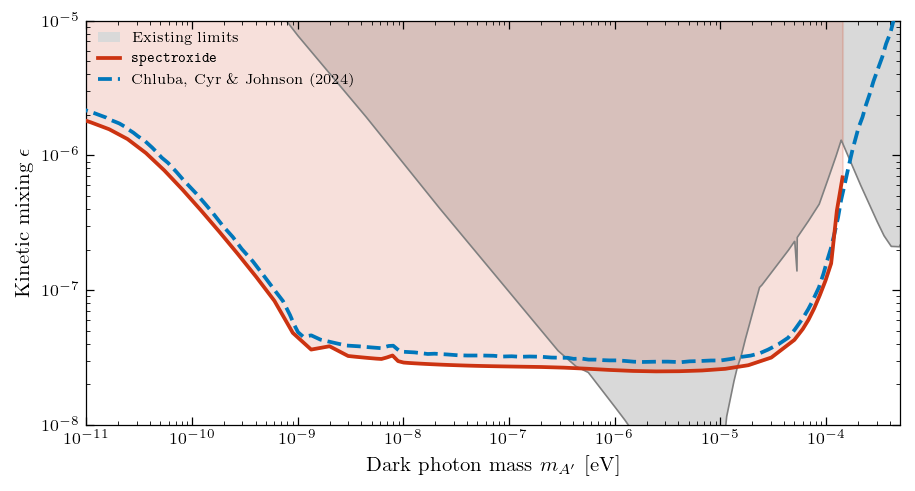

PDE: 70 masses (cut at gamma_con < 0.1)
Strongest: eps < 2.49e-08 at m = 2.46e-06 eV


In [ ]:
cosmotherm_lims = np.loadtxt(PROJECT_ROOT / 'dev' / 'data' / 'cosmotherm_dp_lims.csv', delimiter=',')

# === Publication figure: FIRAS dark photon constraints ===

# Compute gamma_con at the FIRAS limit and cut off where > 0.1.
# Additionally drop masses whose eps_ref iteration did not converge
# (these have bistable/oscillating solutions and should not be plotted).
gc_at_limit = np.array([
    gc_per_eps2(m, pde_results[m]['z_res']) * pde_results[m]['eps_lim']**2
    for m in masses_pde_valid
])
converged_mask = np.array([pde_results[m]['converged'] for m in masses_pde_valid])
valid_mask = (gc_at_limit < 0.1) & converged_mask
dropped_nonconv = masses_pde_valid[~converged_mask]
if len(dropped_nonconv):
    print(f"Dropped {len(dropped_nonconv)} non-converged mass(es) from plot: "
          f"{[float(f'{m:.3e}') for m in dropped_nonconv]}")
masses_plot = masses_pde_valid[valid_mask]
eps_plot = eps_pde[valid_mask]

# --- Existing laboratory limits (non-DM, non-FIRAS) from AxionLimits ---
AL = PROJECT_ROOT / 'dev' / 'AxionLimits' / 'limit_data' / 'DarkPhoton'
xlim = (1e-11, 5e-4)
ylim = (1e-8, 1e-5)

lab_files = [
    'Coulomb.txt', 'Cavendish.txt', 'PlimptonLawton.txt', 'AFM.txt', 'Spectroscopy.txt',
    'CROWS.txt', 'DarkSRF.txt', 'ALPS.txt', 'SPring-8.txt', 'LSW_UWA.txt', 'LSW_ADMX.txt',
]

x_grid = np.geomspace(xlim[0], xlim[1], 3000)
env = np.full_like(x_grid, ylim[1])

for fname in lab_files:
    try:
        d = np.loadtxt(AL / fname)
        m, e = d[:,0], d[:,1]
        mask = (m >= xlim[0]*0.01) & (m <= xlim[1]*100) & np.isfinite(e) & (e > 0)
        if np.sum(mask) < 2: continue
        m, e = m[mask], e[mask]
        idx = np.argsort(m); m, e = m[idx], e[idx]
        e_interp = 10**np.interp(np.log10(x_grid), np.log10(m), np.log10(e),
                                  left=np.log10(ylim[1]), right=np.log10(ylim[1]))
        env = np.minimum(env, e_interp)
    except:
        pass

env = np.clip(env, ylim[0]*0.1, ylim[1])

# --- Plot ---
fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))

# Existing limits (grey envelope)
ax.fill_between(x_grid, env, ylim[1], color='0.85', zorder=0, linewidth=0,
                label=r'Existing limits')
ax.plot(x_grid, env, color='0.5', lw=0.8, zorder=1)

# FIRAS limits
ax.loglog(masses_plot, eps_plot, color=C['red'], lw=LW_THICK, zorder=5,
          label=r'\texttt{spectroxide}')
ax.loglog(cosmotherm_lims[:, 0], cosmotherm_lims[:, 1],
          color=C['blue'], lw=LW_THICK, ls='--', zorder=4,
          label=r"Chluba, Cyr \& Johnson (2024)")
ax.fill_between(masses_plot, eps_plot, ylim[1], alpha=0.15, color=C['red'], zorder=0)

ax.set_xlabel(r"Dark photon mass $m_{A'}$ [eV]")
ax.set_ylabel(r'Kinetic mixing $\epsilon$')
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)

fig.savefig(FIG_DIR / 'dp_firas_pde_constraints.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Summary
print(f'PDE: {len(masses_plot)} masses (cut at gamma_con < 0.1)')
if len(eps_plot) > 0:
    i_best = np.argmin(eps_plot)
    print(f'Strongest: eps < {eps_plot[i_best]:.2e} at m = {masses_plot[i_best]:.2e} eV')

